In [ ]:
### FINDING THE PERCENTAGE OF NAN'S IN THE DATASET PER COLUMN

import pandas as pd
import glob

files = glob.glob("../data/raw/combined_dataset/*.psv")

# List to store NaN % per column for each patient
nan_list = []

for f in files:
    df = pd.read_csv(f, sep='|')
    nan_list.append(df.isna().mean())  # % NaNs per column

# Combine into a DataFrame
nan_df = pd.DataFrame(nan_list)

# Take average % missing per column across all patients
avg_nan = nan_df.mean()
print(avg_nan)


In [ ]:
### DROPPING THE REDUNDANT COLUMNS

import os

# Folder to save processed files
processed_folder = "../data/raw/processed_data"
os.makedirs(processed_folder, exist_ok=True)

# Columns to drop globally (>60% NaNs)
cols_to_drop = avg_nan[avg_nan > 0.6].index.tolist()
print("Columns to drop:", cols_to_drop)

# Process each file and save cleaned version
for f in files:
    df = pd.read_csv(f, sep='|')
    df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    filename = os.path.basename(f)
    df_clean.to_csv(os.path.join(processed_folder, filename), sep='|', index=False)

print("All files cleaned and saved in 'processed_data' folder.")


In [ ]:
### checking the imbalance level of class 

import glob
import pandas as pd
processed_files = glob.glob("../data/raw/processed_data/*.psv")

zeroes = 0
ones = 0 

for f in processed_files:
    df = pd.read_csv(f, sep = '|')
    label = df['SepsisLabel'].iloc[-1]
    if label == 0:
        zeroes += 1
    else: 
        ones += 1

print("zeroes :", zeroes)
print("ones :", ones)

In [ ]:
#### filling remaining NaN's

import pandas as pd
import glob

# path to all .psv files
files = glob.glob("../data/raw/processed_data/*.psv")

for file in files:
    df = pd.read_csv(file, sep='|')
    
    # fill missing values forward, then backward
    df = df.ffill().bfill()
    
    # if anything still NaN (like columns missing all values), fill with column mean
    df = df.fillna(df.mean(numeric_only=True))
    
    # save cleaned file
    cleaned_name = file.replace(".psv", "_cleaned.csv")
    df.to_csv(cleaned_name, index=False)


In [ ]:
##### Condensing multiple time stamps into single row#####

import pandas as pd
import glob

# Path to all cleaned .csv files
files = glob.glob("../data/raw/processed_data/*_cleaned.csv")

# List to store each condensed patient’s row
all_patients = []

for file in files:
    df = pd.read_csv(file)

    # Columns to aggregate
    vital_cols = ['HR', 'O2Sat', 'SBP', 'MAP', 'DBP', 'Resp']

    # Dictionary to hold results for this patient
    condensed = {}

    # Compute mean, std, and last for each vital
    for col in vital_cols:
        if col in df.columns:
            condensed[f"{col}_mean"] = df[col].mean(skipna=True)
            condensed[f"{col}_std"] = df[col].std(skipna=True)
            condensed[f"{col}_last"] = df[col].iloc[-1]

    # Add static columns (take last row value)
    static_cols = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']
    for col in static_cols:
        if col in df.columns:
            condensed[col] = df[col].iloc[-1]

    # Convert to single-row DataFrame and append
    all_patients.append(pd.DataFrame([condensed]))

# Combine all patients into one dataset
final_df = pd.concat(all_patients, ignore_index=True)

# Save the final dataset
final_df.to_csv("../data/raw/processed_data/finaldataset.csv", index=False)

print(f"✅ Condensed dataset created successfully with {final_df.shape[0]} patients and {final_df.shape[1]} features.")


In [ ]:
import glob
len(glob.glob("../data/raw/processed_data/*_cleaned.csv"))


In [ ]:
### checking class imbalance
import pandas as pd

df = pd.read_csv("../data/raw/processed_data/finaldataset.csv")
# Check class distribution
class_counts = df["SepsisLabel"].value_counts()
print(class_counts)

In [4]:
%pip install -r ../requirements.txt


  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.3.4-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp312-cp312-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl (11.0 MB)
Using cached numpy-2.3.4-cp312-cp312-win_amd64.whl (12.8 MB)
Using cached seaborn-0.13.2-py3-

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\DELL\\OneDrive\\Documents\\ML\\mlvenv\\Lib\\site-packages\\sklearn\\naive_bayes.py'
Consider using the `--user` option or check the permissions.



  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl (8.7 MB)
Using cached matplotlib-3.10.7-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)

   ---------------------------------------- 0/4 [contourpy]
   ---------------------------------------- 0/4 [contourpy]
   ---------- ----------------------------- 1/4 [scikit-learn]
   ---------- ----------------------------- 1/4 [scikit-learn]
   ---------- ----------------------------- 1/4 [scikit-learn]
   ---------- ----------------------------- 1/4 [scikit-learn]
   ---------- ----------------------------- 1/4 [scikit-learn]
   ---------- ------

In [4]:
### splitting the data into train and test

import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

# Load your final dataset
df = pd.read_csv("../data/raw/processed_data/finaldataset.csv")

# Separate features (X) and label (y)
X = df.drop(columns=['SepsisLabel'])
y = df['SepsisLabel']

# Split into train and test sets (stratify ensures both sets have similar class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Split completed successfully!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training set class balance:\n{y_train.value_counts()}")
print(f"Testing set class balance:\n{y_test.value_counts()}")


✅ Split completed successfully!
Training samples: 32268
Testing samples: 8068
Training set class balance:
SepsisLabel
0    29922
1     2346
Name: count, dtype: int64
Testing set class balance:
SepsisLabel
0    7482
1     586
Name: count, dtype: int64


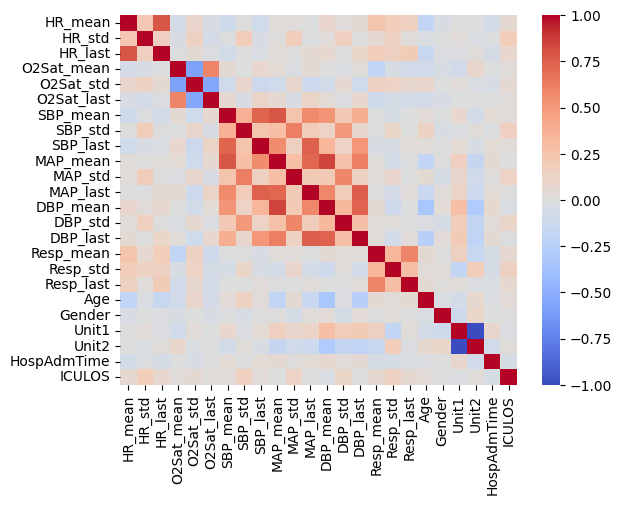

In [11]:
### Heatmap (finding correlation)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(X_train.corr(), cmap='coolwarm')
plt.show()

In [14]:
# ##### remove highly correlated features

# import numpy as np

# # Set your correlation threshold
# threshold = 0.8  # You can change this to 0.85 or 0.95 depending on your case

# # Calculate the correlation matrix
# corr_matrix = X_train.corr().abs()

# # Select the upper triangle of the correlation matrix
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# # Find features with correlation greater than the threshold
# to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# # Drop the highly correlated features
# X_train_reduced = X_train.drop(columns=to_drop)

# print("Dropped columns due to high correlation:", to_drop)
# print("Shape before:", X_train.shape)
# print("Shape after:", X_train_reduced.shape)


In [2]:
%pip install -r ../requirements.txt

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.3.4-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.16.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttoo

In [16]:
### fixing class imbalance by applying SMOTE

from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

# Apply only on training set
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new balance
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 SepsisLabel
0    29922
1     2346
Name: count, dtype: int64

After SMOTE:
 SepsisLabel
0    29922
1    29922
Name: count, dtype: int64


In [17]:
### saving train and test data

import pandas as pd

# Combine X and y for convenience
train_resampled = pd.concat([pd.DataFrame(X_train_res, columns=X_train.columns),
                             pd.Series(y_train_res, name='SepsisLabel')], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Save to CSV
train_resampled.to_csv("../data/raw/processed_data/train_resampled.csv", index=False)
test_data.to_csv("../data/raw/processed_data/test_data.csv", index=False)
